# Simple Moving Average Crossover Strategy

> **Educational disclaimer:** This notebook is for learning and research purposes only. It is not financial advice, investment advice, or a recommendation to buy or sell any asset.

This notebook demonstrates a classic trend-following strategy using simple moving averages.

## Introduction

A **simple moving average (SMA)** is the average price over a rolling window of time. It smooths noisy price data and makes broader market trends easier to see.

A **crossover strategy** compares two moving averages with different speeds:

- a faster moving average that reacts more quickly to price changes
- a slower moving average that reacts more gradually

A common setup is the **50-day** and **200-day** moving average pair. Traders often use these because they provide a simple way to compare medium-term and long-term trend direction.

This is a basic **trend-following strategy**. The idea is simple: stay invested when the shorter average is above the longer average, and step aside when it is not.

## 1. Import Libraries

We use `pandas` for time series handling, `numpy` for vectorized calculations, and `matplotlib` for visualization.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')

## 2. Load the CSV Data

The notebook expects a file named `EURUSD.csv` in the same folder as this notebook. We detect common date and price column names automatically so the notebook is more tolerant of small naming differences.

If the CSV is not available, the notebook creates a reproducible synthetic EUR/USD-style price series so the full workflow still runs.

In [2]:
def create_synthetic_eurusd_data(seed=42):
    """Create reproducible EUR/USD-style daily data as a fallback."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start='2018-01-02', end='2024-12-31')

    # Simulate realistic FX-like daily moves with modest volatility.
    daily_returns = rng.normal(loc=0.00002, scale=0.0035, size=len(dates))
    price = 1.18 * np.cumprod(1 + daily_returns)

    data = pd.DataFrame({'price': price}, index=dates)
    data.index.name = 'Date'
    return data, 'Synthetic EUR/USD fallback data', 'price'


def find_datetime_column(dataframe):
    """Find a likely datetime column using common names first, then parsability."""
    common_datetime_columns = ['Date', 'date', 'Datetime', 'DateTime', 'Timestamp', 'timestamp', 'time', 'Time']

    for column in common_datetime_columns:
        if column in dataframe.columns:
            return column

    for column in dataframe.columns:
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            continue

        parsed_dates = pd.to_datetime(dataframe[column], errors='coerce')
        if parsed_dates.notna().mean() > 0.80:
            return column

    raise ValueError('Could not identify a datetime column in EURUSD.csv.')


def find_price_column(dataframe):
    """Find a likely price column using common finance names first, then numeric fallback."""
    common_price_columns = ['Adj Close', 'Adj_Close', 'Close', 'close', 'Price', 'price']

    for column in common_price_columns:
        if column in dataframe.columns:
            return column

    numeric_columns = []
    for column in dataframe.columns:
        numeric_series = pd.to_numeric(dataframe[column], errors='coerce')
        if numeric_series.notna().mean() > 0.80:
            numeric_columns.append(column)

    if len(numeric_columns) == 0:
        raise ValueError('Could not identify a usable price column in EURUSD.csv.')

    return numeric_columns[0]


csv_path = Path('EURUSD.csv')

if csv_path.exists():
    raw_data = pd.read_csv(csv_path)
    datetime_column = find_datetime_column(raw_data)
    price_column = find_price_column(raw_data.drop(columns=[datetime_column], errors='ignore'))

    raw_data[datetime_column] = pd.to_datetime(raw_data[datetime_column], errors='coerce')
    raw_data = raw_data.dropna(subset=[datetime_column]).set_index(datetime_column).sort_index()
    raw_data.index.name = 'Date'

    data_source = f'Loaded from {csv_path}'
else:
    raw_data, data_source, price_column = create_synthetic_eurusd_data()
    datetime_column = raw_data.index.name

print(f'Data source:          {data_source}')
print(f'Datetime column used: {datetime_column}')
print(f'Price column used:    {price_column}')
raw_data.head()

Data source:          Synthetic EUR/USD fallback data
Datetime column used: Date
Price column used:    price


,price
Date,
2018-01-02,1.181282
2018-01-03,1.177006
2018-01-04,1.180121
2018-01-05,1.184029
2018-01-08,1.175968


After loading the file, we inspect the first few rows and basic structure to confirm that the data looks correct.

In [3]:
raw_data.head()

,price
Date,
2018-01-02,1.181282
2018-01-03,1.177006
2018-01-04,1.180121
2018-01-05,1.184029
2018-01-08,1.175968


In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2018-01-02 to 2024-12-31
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   1826 non-null   float64
dtypes: float64(1)
memory usage: 28.5 KB


## 3. Clean the Dataset

For the strategy itself, we only need one working price series. We keep that column, drop missing values, and rename it to `price`.

In [5]:
df = raw_data[[price_column]].copy()
df.columns = ['price']
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna().sort_index()

print(f'Clean date range: {df.index.min().date()} to {df.index.max().date()}')
print(f'Observations:     {len(df):,}')
df.head()

Clean date range: 2018-01-02 to 2024-12-31
Observations:     1,826


,price
Date,
2018-01-02,1.181282
2018-01-03,1.177006
2018-01-04,1.180121
2018-01-05,1.184029
2018-01-08,1.175968


## 4. Calculate Moving Averages

We calculate the two trend filters used in the strategy:

- `SMA_50`: a faster 50-day average
- `SMA_200`: a slower 200-day average

In [6]:
df['SMA_50'] = df['price'].rolling(window=50).mean()
df['SMA_200'] = df['price'].rolling(window=200).mean()

df[['price', 'SMA_50', 'SMA_200']].head(210).tail()

,price,SMA_50,SMA_200
Date,,,
2018-10-16,1.160280,1.150626,1.167714
2018-10-17,1.156879,1.150847,1.167642
2018-10-18,1.151967,1.150892,1.167552
2018-10-19,1.148450,1.150905,1.167445
2018-10-22,1.147130,1.150987,1.167349


## 5. Create the Trading Signal

The core trading rule is straightforward:

- `signal = 1` when `SMA_50 > SMA_200`
- `signal = 0` otherwise

We also create a `position` column to identify the moments when the signal changes.

In [7]:
df['signal'] = np.where(df['SMA_50'] > df['SMA_200'], 1, 0)

# position highlights changes in the signal: positive values for bullish entries,
# negative values for bearish exits.
df['position'] = df['signal'].diff()

df[['price', 'SMA_50', 'SMA_200', 'signal', 'position']].tail()

,price,SMA_50,SMA_200,signal,position
Date,,,,,
2024-12-25,0.918600,0.934966,0.968155,0,0.000000
2024-12-26,0.922546,0.934606,0.967727,0,0.000000
2024-12-27,0.924646,0.934175,0.967289,0,0.000000
2024-12-30,0.921817,0.933613,0.966834,0,0.000000
2024-12-31,0.924010,0.933075,0.966369,0,0.000000


## 6. Plot the Price, Averages, and Crossover Points

We mark:

- **bullish crossovers** where the signal changes from `0` to `1`
- **bearish crossovers** where the signal changes from `1` to `0`

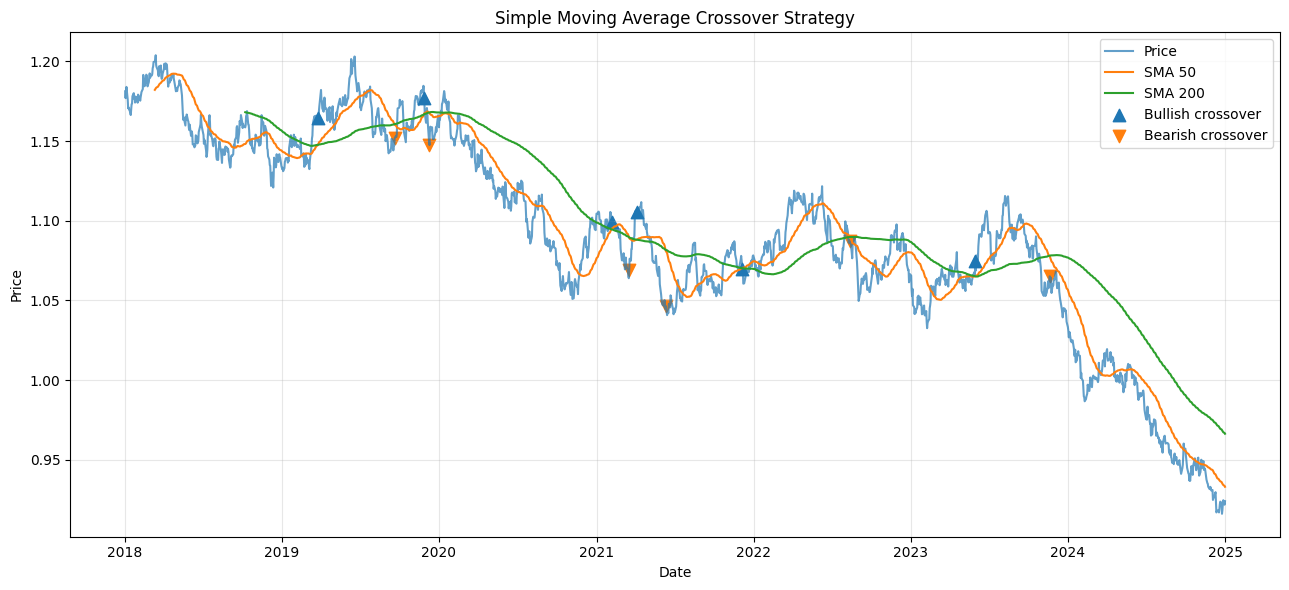

In [8]:
bullish_crossovers = df[df['position'] == 1]
bearish_crossovers = df[df['position'] == -1]

plt.figure(figsize=(13, 6))
plt.plot(df.index, df['price'], label='Price', alpha=0.7)
plt.plot(df.index, df['SMA_50'], label='SMA 50', linewidth=1.5)
plt.plot(df.index, df['SMA_200'], label='SMA 200', linewidth=1.5)

plt.scatter(
    bullish_crossovers.index,
    bullish_crossovers['price'],
    label='Bullish crossover',
    marker='^',
    s=80,
)
plt.scatter(
    bearish_crossovers.index,
    bearish_crossovers['price'],
    label='Bearish crossover',
    marker='v',
    s=80,
)

plt.title('Simple Moving Average Crossover Strategy')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Compute Daily Returns and Strategy Returns

We calculate simple daily returns from price.

To avoid **look-ahead bias**, we shift the trading signal by one day before multiplying it by returns. That means today's strategy return uses yesterday's known signal, not today's signal derived from today's closing data.

In [9]:
df['daily_return'] = df['price'].pct_change(fill_method=None)

# Shift the signal so the strategy only acts on information that would have been known
# at the close of the previous period.
df['strategy_return'] = df['daily_return'] * df['signal'].shift(1)

df[['price', 'signal', 'daily_return', 'strategy_return']].head()

,price,signal,daily_return,strategy_return
Date,,,,
2018-01-02,1.181282,0,NaN,NaN
2018-01-03,1.177006,0,-0.003620,-0.000000
2018-01-04,1.180121,0,0.002647,0.000000
2018-01-05,1.184029,0,0.003312,0.000000
2018-01-08,1.175968,0,-0.006809,-0.000000


## 8. Compare Buy-and-Hold vs Strategy Performance

We build cumulative return series for both approaches:

- **buy-and-hold**: always invested
- **strategy**: invested only when the signal is active

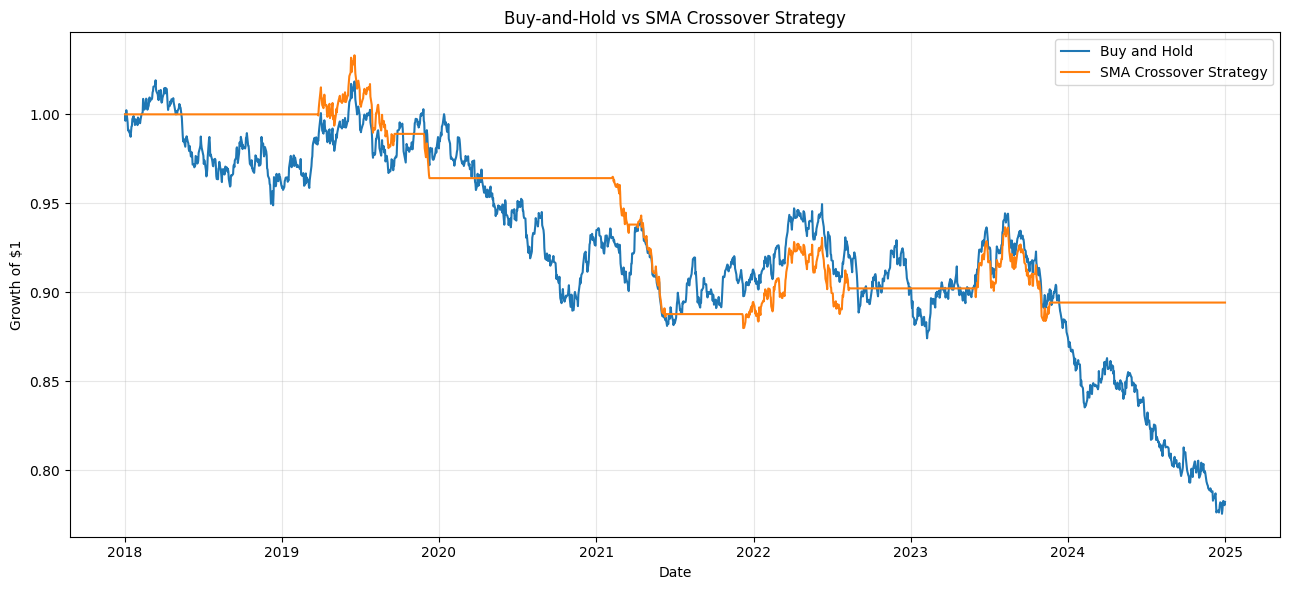

In [10]:
df['buy_hold_cumulative'] = (1 + df['daily_return'].fillna(0)).cumprod()
df['strategy_cumulative'] = (1 + df['strategy_return'].fillna(0)).cumprod()

plt.figure(figsize=(13, 6))
plt.plot(df.index, df['buy_hold_cumulative'], label='Buy and Hold')
plt.plot(df.index, df['strategy_cumulative'], label='SMA Crossover Strategy')
plt.title('Buy-and-Hold vs SMA Crossover Strategy')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary Statistics

We now calculate several simple performance metrics:

- total return
- annualized return
- annualized volatility
- Sharpe ratio (assuming risk-free rate = 0)
- maximum drawdown

In [11]:
def calculate_performance_metrics(return_series):
    """Calculate basic strategy performance metrics from a daily return series."""
    returns = return_series.dropna()

    if len(returns) == 0:
        raise ValueError('Return series is empty. Cannot calculate performance metrics.')

    cumulative = (1 + returns).cumprod()
    total_return = cumulative.iloc[-1] - 1
    annualized_return = returns.mean() * 252
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan

    cumulative_max = cumulative.cummax()
    drawdown = (cumulative - cumulative_max) / cumulative_max
    maximum_drawdown = drawdown.min()

    return {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': maximum_drawdown,
    }


buy_hold_metrics = calculate_performance_metrics(df['daily_return'])
strategy_metrics = calculate_performance_metrics(df['strategy_return'])

metrics_table = pd.DataFrame(
    {
        'Buy and Hold': buy_hold_metrics,
        'SMA Crossover Strategy': strategy_metrics,
    }
)

metrics_table

,Buy and Hold,SMA Crossover Strategy
Total Return,-0.217791,-0.105771
Annualized Return,-0.032360,-0.014981
Annualized Volatility,0.055784,0.030179
Sharpe Ratio,-0.580093,-0.496391
Maximum Drawdown,-0.239035,-0.148392


## 10. EMA Variation (Optional)

One easy extension is to replace simple moving averages with exponential moving averages (EMAs).

The structure of the strategy barely changes. Only the moving average calculation changes.

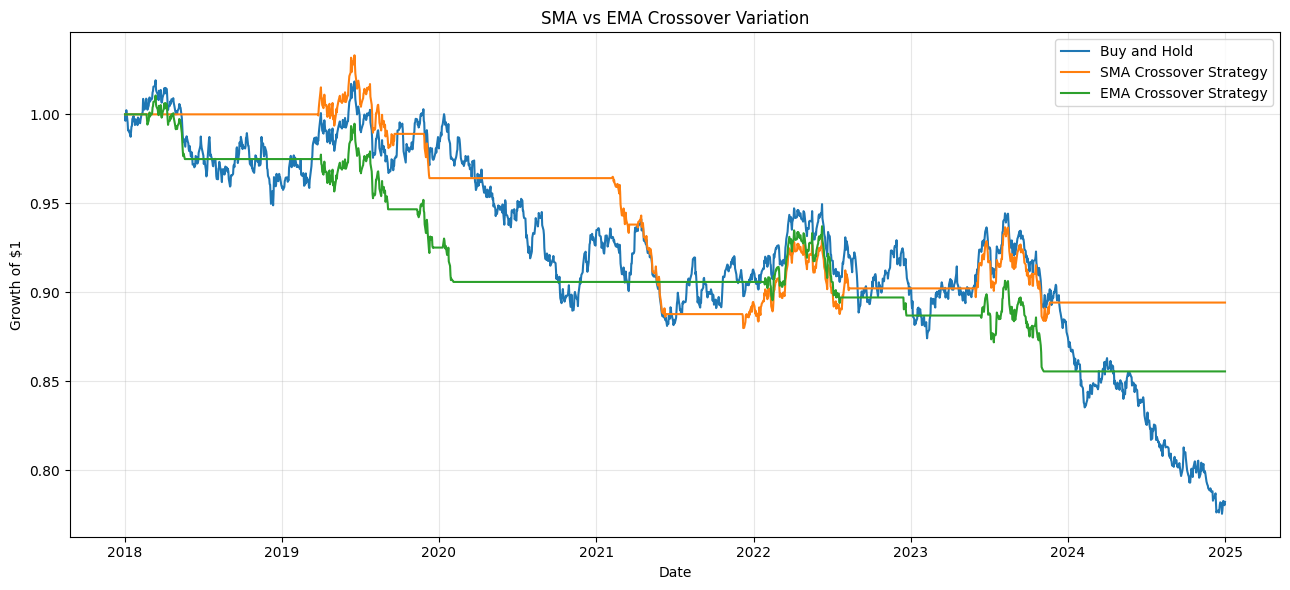

In [12]:
df['EMA_50'] = df['price'].ewm(span=50, adjust=False).mean()
df['EMA_200'] = df['price'].ewm(span=200, adjust=False).mean()
df['ema_signal'] = np.where(df['EMA_50'] > df['EMA_200'], 1, 0)
df['ema_strategy_return'] = df['daily_return'] * df['ema_signal'].shift(1)
df['ema_strategy_cumulative'] = (1 + df['ema_strategy_return'].fillna(0)).cumprod()

plt.figure(figsize=(13, 6))
plt.plot(df.index, df['buy_hold_cumulative'], label='Buy and Hold')
plt.plot(df.index, df['strategy_cumulative'], label='SMA Crossover Strategy')
plt.plot(df.index, df['ema_strategy_cumulative'], label='EMA Crossover Strategy')
plt.title('SMA vs EMA Crossover Variation')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

Crossover strategies attempt to capture sustained market trends by comparing a fast trend estimate with a slower one.

**Strengths:**

- simple to understand
- easy to implement
- useful for broad trend detection

**Weaknesses:**

- moving averages are lagging indicators
- signals can arrive late
- sideways markets often create repeated false signals, sometimes called **whipsaws**

Like any trading idea, crossover performance depends on the asset, the time period, the parameter choices, and real-world factors such as transaction costs and execution.